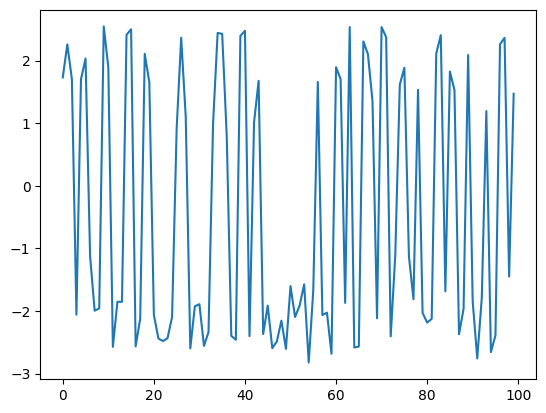

USB read error
USB read error


(array([ 0.22619467, -6.32104146]), {})

In [1]:
import gym_unbalanced_disk
import gymnasium
import numpy as np
from matplotlib import pyplot as plt

#create inputs
umax = 3.0 
np.random.seed(46)
ulist = np.random.uniform(-1,1,size=1000)
from scipy import signal
f0 = 0.8
ulist = signal.lfilter(*signal.butter(6,f0),ulist)
ulist /= max(np.max(ulist),-np.min(ulist))
ulist = umax*abs(ulist)**(1/4)*np.sign(ulist) #push to limits

plt.plot(ulist[:100])
plt.show()

env = gym_unbalanced_disk.UnbalancedDisk_exp(umax = umax,dt = 0.025)

obs, info = env.reset()
ylist = []
for u in ulist:
    ylist.append(obs)
    obs, reward, terminal, truncated, info = env.step(u)
env.reset()


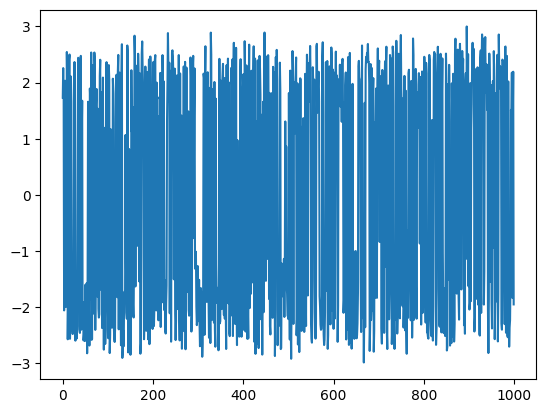

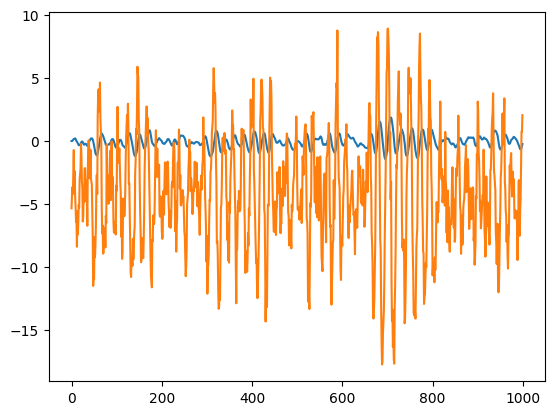

In [2]:
plt.plot(ulist) 
plt.show()
plt.plot(ylist)
plt.show()

In [3]:
env.close()

In [ ]:
env = gymnasium.make('unbalanced-disk-exp-v0', dt=0.025, umax=3.) #both are equivalent (this one has a time limit build in)
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #both are equivalent

: 

### Load model and run it on the setup

In [ ]:
from pathlib import Path

import numpy as np
from stable_baselines3 import A2C

# Hardware sin/cos environment: connects through UnbalancedDisk_exp and returns
# the model observation [sin(theta), cos(theta), omega].
MODEL_NAME = "a2c_unbalanced_disk_long_stable.zip"  # use "a2c_unbalanced_disk_long_dual.zip" for the dual policy
MODEL_CANDIDATES = [
    Path.cwd() / MODEL_NAME,
    Path.cwd() / "ML-for-control-systems-Pendulum" / "gym-unbalanced-disk-master" / "gym_unbalanced_disk" / "examples-connect-to-exp" / MODEL_NAME,
]
MODEL_PATH = next((path for path in MODEL_CANDIDATES if path.exists()), MODEL_CANDIDATES[0])
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find {MODEL_NAME}. Checked: {MODEL_CANDIDATES}")

RUN_STEPS = 1200
DETERMINISTIC = True
ACTION_SIGN = 1.0  # try -1.0 if the real setup polarity is opposite to the simulator
PRINT_FIRST_STEPS = 20

model = A2C.load(MODEL_PATH, device="cpu")
env = gym_unbalanced_disk.UnbalancedDisk_exp_sincos(dt=0.025, umax=umax)

ylist, u_model_list, u_applied_list = [], [], []

try:
    obs, info = env.reset()
    for k in range(RUN_STEPS):
        action, _ = model.predict(obs.astype(np.float32), deterministic=DETERMINISTIC)
        u_model = float(np.asarray(action).reshape(-1)[0])
        u_applied = float(np.clip(ACTION_SIGN * u_model, -umax, umax))

        ylist.append(obs)
        u_model_list.append(u_model)
        u_applied_list.append(u_applied)

        if k < PRINT_FIRST_STEPS:
            print(f"k={k:03d} obs={np.round(obs, 3)} model_u={u_model:+.3f} applied_u={u_applied:+.3f}")

        obs, reward, terminal, truncated, info = env.step(u_applied)
        if terminal or truncated:
            break
finally:
    try:
        env.step(0.0)
    finally:
        env.close()

ylist = np.asarray(ylist)
u_model_list = np.asarray(u_model_list)
u_applied_list = np.asarray(u_applied_list)

print(f"Ran loaded model for {len(u_applied_list)} setup steps")
if len(u_applied_list):
    print(f"max |model_u| = {np.max(np.abs(u_model_list)):.2f} V")
    print(f"max |applied_u| = {np.max(np.abs(u_applied_list)):.2f} V")

plt.plot(u_model_list, label="model")
plt.plot(u_applied_list, label="applied", linestyle="--")
plt.title("Model and applied voltage command")
plt.legend()
plt.show()

plt.plot(ylist)
plt.title("Setup observations: sin(theta), cos(theta), omega")
plt.show()
